# Coding-region zero-shot AUROC (ClinVar SNVs)

For every sample we score the **mutant** and the **wild-type** sequence
through the DeepD inference API (`logits` task).  The API returns the
mean negative log-likelihood `loss` of a sequence;   The variant score is
the variant-vs-WT perplexity difference

```
score = exp(-ll_mut) - exp(-ll_wt)
```



In [1]:
import json
import os
import re
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import rankdata

# --- locate the inference gateway client -----------------------------------
REPO = Path.cwd().resolve()
while not (REPO / "apiexample" / "cli.py").is_file():
    if REPO.parent == REPO:
        raise FileNotFoundError("cannot locate apiexample/cli.py")
    REPO = REPO.parent
CLI = REPO / "apiexample" / "cli.py"
SCORE_CACHE = REPO / "notebook" / "zero_shot" / "api_scores"
SCORE_CACHE.mkdir(parents=True, exist_ok=True)

# --- API token -------------------------------------------------------------
TOKEN = os.environ.get("INFERENCE_API_TOKEN", "").strip()
if not TOKEN:
    for key_file in (REPO / "API-Key.txt", REPO / "apiexample" / "API-Key.txt"):
        if not key_file.is_file():
            continue
        for line in key_file.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and all(ord(c) < 128 for c in line):
                TOKEN = line
                break
        if TOKEN:
            break
assert TOKEN, "no API token (set INFERENCE_API_TOKEN or API-Key.txt)"
ENV = dict(os.environ, INFERENCE_API_TOKEN=TOKEN)


def score_sequence(seq, tag):
    """Score one sequence with the `logits` API; return mean NLL (loss)."""
    cache = SCORE_CACHE / f"{tag}.json"
    if cache.exists():
        return float(json.loads(cache.read_text(encoding="utf-8"))["loss"])
    cmd = [sys.executable, str(CLI), "--prompt", seq, "--task-type", "logits",
           "--species", "Homo sapiens", "--output-dir", str(SCORE_CACHE)]
    proc = subprocess.run(cmd, env=ENV, capture_output=True, text=True, timeout=3600)
    if proc.returncode != 0:
        raise RuntimeError(proc.stdout[-2000:] + proc.stderr[-2000:])
    match = re.search(r"\[done\] saved:\s*(\S+)", proc.stdout)
    newest = Path(match.group(1)) if match else None
    if newest is None or not newest.is_file():
        newest = max(SCORE_CACHE.glob("*.json"), key=lambda p: p.stat().st_mtime)
    doc = json.loads(newest.read_text(encoding="utf-8"))
    inner = doc.get("result", doc)
    while isinstance(inner, dict) and "result" in inner and isinstance(inner["result"], dict):
        inner = inner["result"]
    out = {"loss": float(inner["loss"]), "ppl": inner.get("ppl")}
    cache.write_text(json.dumps(out, indent=2), encoding="utf-8")
    print(f"  scored {tag}: loss={out['loss']:.4f}")
    return out["loss"]

In [2]:
df = pd.read_csv("clinvar_snv_coding.csv")
print(f"loaded {len(df)} samples (mut + wt sequence each)\n")

mut_loss, wt_loss = {}, {}
for i, row in df.iterrows():
    uid = row["unique_id"]
    mut_loss[uid] = score_sequence(row["mut_seq"], f"{uid}_mut")
    wt_loss[uid] = score_sequence(row["wt_seq"], f"{uid}_wt")
    if (i + 1) % 20 == 0 or i == len(df) - 1:
        print(f"scored {i + 1}/{len(df)} samples", flush=True)

def auroc(y, s):
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
    ranks = rankdata(s)
    u = ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2.0
    return u / (n_pos * n_neg)

y = df["label"].astype(int).to_numpy()
# API returns `loss` = mean per-token NLL; log-likelihood is ll = -loss,
# perplexity is ppl = exp(-ll) = exp(loss).
ll_mut = -np.array([mut_loss[u] for u in df["unique_id"]])
ll_wt = -np.array([wt_loss[u] for u in df["unique_id"]])
score = np.exp(-ll_mut) - np.exp(-ll_wt)   # == ppl_mut - ppl_wt
auc = auroc(y, score)
print(f"AUROC = {auc:.4f}")

loaded 184 samples (mut + wt sequence each)

scored 20/184 samples


scored 40/184 samples


scored 60/184 samples


scored 80/184 samples


scored 100/184 samples


...

scored 140/184 samples


scored 160/184 samples


scored 180/184 samples


scored 184/184 samples


AUROC = 0.8726


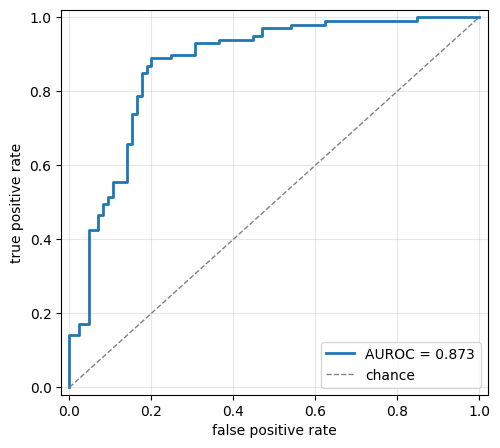

In [3]:
# ROC curve.
import matplotlib.pyplot as plt
order = np.argsort(-score, kind="mergesort")
ys_ = y[order]
tpr = np.concatenate([[0.0], np.cumsum(ys_) / ys_.sum()])
fpr = np.concatenate([[0.0], np.cumsum(1 - ys_) / (ys_ == 0).sum()])

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.plot(fpr, tpr, lw=2, color="#1f77b4", label=f"AUROC = {auc:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="chance")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.show()